# Bayesian Ordinal Regression with Horseshoe Priors and Monotonic Effects

This analysis extends the basic ordinal regression model to include multiple predictors using **regularized horseshoe priors** combined with **monotonic effects** for ordinal predictors.

## Why Monotonic Effects for Ordinal Predictors?

Most of our predictors are ordinal categorical variables (e.g., depression severity on a 1-5 scale). Treating them as continuous assumes equal spacing between categories, which is the same problematic assumption we avoid for the outcome. Instead, we use **monotonic effects** that:

- **Respect ordinality**: Effects can only increase (or decrease) across levels
- **Allow unequal spacing**: The data determines how much effect changes between adjacent levels
- **Provide interpretable parameters**: A scale (direction/magnitude) and shape (relative increments)

## Why Horseshoe Priors?

With multiple correlated predictors, the horseshoe prior provides:

- **Adaptive shrinkage**: Small effects shrunk toward zero, large effects preserved
- **Handles multicollinearity**: Identifies which predictors carry unique information
- **Sparsity**: Encourages parsimonious models

## Predictors

**Ordinal Mental Health Variables (monotonic effects):**
- `hlthdep`: Health depression scale (1-5)
- `feeldown`: Feeling down, depressed, or hopeless (1-4)
- `nointerest`: Little interest or pleasure in doing things (1-4)
- `feelnerv`: Feeling nervous, anxious, or on edge (1-4)
- `worry`: Not being able to stop or control worrying (1-4)

**Ordinal Work Variable (monotonic effect):**
- `wrkmeangfl`: I find my work to be very meaningful (1-4: strongly agree to strongly disagree)

**Continuous/Binary (standard effects):**
- `age`: Age in years (standardized)
- `female`: Binary indicator

In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

np.random.seed(42)
pd.set_option('display.max_columns', None)

print(f'PyMC version: {pm.__version__}')
print(f'ArviZ version: {az.__version__}')

PyMC version: 5.25.1
ArviZ version: 0.22.0


## Data Loading and Preparation

In [2]:
# Load data
df = pd.read_csv('data/gss_subset.csv')
print(f'Full dataset: {df.shape}')

# Define variable groups
ordinal_predictors = ['hlthdep', 'feeldown', 'nointerest', 'feelnerv', 'worry', 'wrkmeangfl']
outcome = 'satjob'

# Select and clean
analysis_cols = [outcome] + ordinal_predictors + ['age', 'sex']
df_analysis = df[analysis_cols].dropna().copy()
df_analysis = df_analysis[df_analysis['satjob'].isin([1.0, 2.0, 3.0, 4.0])].copy()

print(f'Analysis dataset: {df_analysis.shape}')
print(f'Complete cases: {len(df_analysis)}')

Full dataset: (75699, 16)
Analysis dataset: (554, 9)
Complete cases: 554


In [3]:
# Examine ordinal predictor levels
print('Ordinal predictor levels:')
ordinal_levels = {}
for var in ordinal_predictors:
    levels = sorted(df_analysis[var].unique())
    ordinal_levels[var] = len(levels)
    print(f'  {var}: {len(levels)} levels {levels}')

print(f'\nOutcome (satjob): {sorted(df_analysis[outcome].unique())}')

Ordinal predictor levels:
  hlthdep: 5 levels [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
  feeldown: 4 levels [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  nointerest: 4 levels [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  feelnerv: 4 levels [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  worry: 4 levels [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  wrkmeangfl: 4 levels [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]

Outcome (satjob): [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


In [4]:
# Prepare outcome (0-indexed)
df_analysis['y'] = (df_analysis['satjob'] - 1).astype(int)

# Convert ordinal predictors to 0-indexed integers
for var in ordinal_predictors:
    df_analysis[f'{var}_idx'] = (df_analysis[var] - 1).astype(int)

# Binary sex indicator
df_analysis['female'] = (df_analysis['sex'] == 2).astype(int)

# Standardize age
age_mean = df_analysis['age'].mean()
age_std = df_analysis['age'].std()
df_analysis['age_std'] = (df_analysis['age'] - age_mean) / age_std

# Display summary
print('Prepared variables:')
print(df_analysis[['y'] + [f'{v}_idx' for v in ordinal_predictors] + ['age_std', 'female']].describe())

Prepared variables:
                y  hlthdep_idx  feeldown_idx  nointerest_idx  feelnerv_idx  \
count  554.000000   554.000000    554.000000      554.000000    554.000000   
mean     0.696751     1.184116      0.458484        0.406137      0.658845   
std      0.780706     1.132473      0.762533        0.708536      0.863696   
min      0.000000     0.000000      0.000000        0.000000      0.000000   
25%      0.000000     0.000000      0.000000        0.000000      0.000000   
50%      1.000000     1.000000      0.000000        0.000000      0.000000   
75%      1.000000     2.000000      1.000000        1.000000      1.000000   
max      3.000000     4.000000      3.000000        3.000000      3.000000   

        worry_idx  wrkmeangfl_idx       age_std      female  
count  554.000000      554.000000  5.540000e+02  554.000000  
mean     0.577617        0.853791  9.138298e-17    0.483755  
std      0.849596        0.730574  1.000000e+00    0.500188  
min      0.000000        0.00

In [5]:
# Visualize ordinal predictor distributions
fig = make_subplots(rows=2, cols=3, subplot_titles=ordinal_predictors)

for i, var in enumerate(ordinal_predictors):
    row, col = i // 3 + 1, i % 3 + 1
    counts = df_analysis[var].value_counts().sort_index()
    fig.add_trace(
        go.Bar(x=[str(int(x)) for x in counts.index], y=counts.values, 
               name=var, showlegend=False),
        row=row, col=col
    )

fig.update_layout(height=400, title='Ordinal Predictor Distributions')
fig.show()

In [6]:
# Correlation matrix
corr_vars = ordinal_predictors + ['age', 'female']
corr_matrix = df_analysis[corr_vars].corr()

fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu_r',
    zmin=-1, zmax=1,
    text=np.round(corr_matrix.values, 2),
    texttemplate='%{text}'
))
fig.update_layout(title='Predictor Correlations', width=600, height=500)
fig.show()

print('Note: High correlations among mental health variables - horseshoe will help identify unique contributions.')

Note: High correlations among mental health variables - horseshoe will help identify unique contributions.


## Monotonic Effects: Theory

For an ordinal predictor with $K$ levels (0 to $K-1$), the monotonic effect at level $k$ is:

$$\text{effect}_k = b \cdot \sum_{j=0}^{k-1} \delta_j$$

where:
- $b$ is the **scale parameter** (total effect from lowest to highest level, can be positive or negative)
- $\boldsymbol{\delta} = (\delta_0, \ldots, \delta_{K-2})$ is a **simplex** (sums to 1) determining the shape

This means:
- Level 0: effect = 0 (reference)
- Level 1: effect = $b \cdot \delta_0$
- Level 2: effect = $b \cdot (\delta_0 + \delta_1)$
- Level $K-1$: effect = $b$ (full effect)

The simplex prior $\boldsymbol{\delta} \sim \text{Dirichlet}(\mathbf{1})$ is uniform over all possible shapes.

We apply horseshoe priors to the scale parameters $b$ to achieve shrinkage.

In [7]:
# Prepare data for model
y = df_analysis['y'].values
N = len(y)
K_outcome = 4  # outcome categories

# Ordinal predictor indices (0-indexed)
ordinal_data = {var: df_analysis[f'{var}_idx'].values for var in ordinal_predictors}
ordinal_K = {var: ordinal_levels[var] for var in ordinal_predictors}  # number of levels

# Continuous predictors
age_std = df_analysis['age_std'].values
female = df_analysis['female'].values

# For horseshoe: number of scale parameters to regularize
n_ordinal = len(ordinal_predictors)
n_continuous = 2  # age, female
D = n_ordinal + n_continuous
D0 = 3  # expected number of important predictors

print(f'Observations: {N}')
print(f'Total predictors: {D} ({n_ordinal} ordinal + {n_continuous} continuous)')
print(f'Ordinal levels: {ordinal_K}')

Observations: 554
Total predictors: 8 (6 ordinal + 2 continuous)
Ordinal levels: {'hlthdep': 5, 'feeldown': 4, 'nointerest': 4, 'feelnerv': 4, 'worry': 4, 'wrkmeangfl': 4}


In [8]:
# Define model with monotonic effects and horseshoe priors
predictor_names = ordinal_predictors + ['age', 'female']

with pm.Model(coords={'predictors': predictor_names, 
                      'ordinal_predictors': ordinal_predictors}) as model:
    
    # === Horseshoe Prior on Scale Parameters ===
    tau0 = D0 / (D - D0) / np.sqrt(N)
    tau = pm.HalfStudentT('tau', nu=2, sigma=tau0)
    lam = pm.HalfStudentT('lam', nu=5, sigma=1, dims='predictors')
    c2 = pm.InverseGamma('c2', alpha=1, beta=1)
    lam_tilde = lam * pt.sqrt(c2 / (c2 + tau**2 * lam**2))
    
    # Raw scales (non-centered)
    z = pm.Normal('z', 0, 1, dims='predictors')
    b = pm.Deterministic('b', z * tau * lam_tilde, dims='predictors')
    
    # === Monotonic Effects for Ordinal Predictors ===
    eta = pm.Normal('mu', 0, 2)  # intercept
    
    for i, var in enumerate(ordinal_predictors):
        K_var = ordinal_K[var]
        x_idx = ordinal_data[var]
        
        # Simplex for shape (K-1 increments that sum to 1)
        delta = pm.Dirichlet(f'delta_{var}', a=np.ones(K_var - 1))
        
        # Cumulative sum gives effect at each level (0 at level 0)
        cumsum = pt.concatenate([[0], pt.cumsum(delta)])
        
        # Effect = scale * cumulative simplex, indexed by observation
        effect = b[i] * cumsum[x_idx]
        eta = eta + effect
    
    # === Standard Effects for Continuous/Binary ===
    eta = eta + b[n_ordinal] * age_std      # age effect
    eta = eta + b[n_ordinal + 1] * female   # female effect
    
    eta = pm.Deterministic('eta', eta)
    
    # === Ordinal Outcome ===
    cutpoints = pm.Normal('cutpoints', mu=[-1, 0, 1], sigma=2, shape=K_outcome-1,
                         transform=pm.distributions.transforms.ordered)
    
    y_obs = pm.OrderedLogistic('y_obs', cutpoints=cutpoints, eta=eta, observed=y)
    
    # Prior predictive
    prior = pm.sample_prior_predictive(500, random_seed=42)

print('Model parameters:')
print(f'  Scale parameters (b): {len(predictor_names)}')
print(f'  Simplex parameters (delta): {sum(ordinal_K[v]-1 for v in ordinal_predictors)}')
print(f'  Cutpoints: {K_outcome - 1}')

Sampling: [c2, cutpoints, delta_feeldown, delta_feelnerv, delta_hlthdep, delta_nointerest, delta_worry, delta_wrkmeangfl, lam, mu, tau, y_obs, z]


Model parameters:
  Scale parameters (b): 8
  Simplex parameters (delta): 19
  Cutpoints: 3


ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: random_make_inplace
ERROR (pytensor.graph.rewriting.basic): node: t_rv{"(),(),()->()"}(*0-<RandomGeneratorType>, *1-<NoneTypeT>, *2-<Scalar(int8, shape=())>, 0.0, *3-<Scalar(float64, shape=())>)
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/var/home/fonnesbeck/.local/lib/python3.13/site-packages/pytensor/graph/rewriting/basic.py", line 1922, in process_node
    replacements = node_rewriter.transform(fgraph, node)
  File "/var/home/fonnesbeck/.local/lib/python3.13/site-packages/pytensor/graph/rewriting/basic.py", line 1086, in transform
    return self.fn(fgraph, node)
           ~~~~~~~^^^^^^^^^^^^^^
  File "/var/home/fonnesbeck/.local/lib/python3.13/site-packages/pytensor/tensor/random/rewriting/basic.py", line 50, in random_make_inplace
    new_outputs = new_op.make_node(*node.inputs).outputs
                  ~~~~~~~~~~~~~~~~^^^^^^^

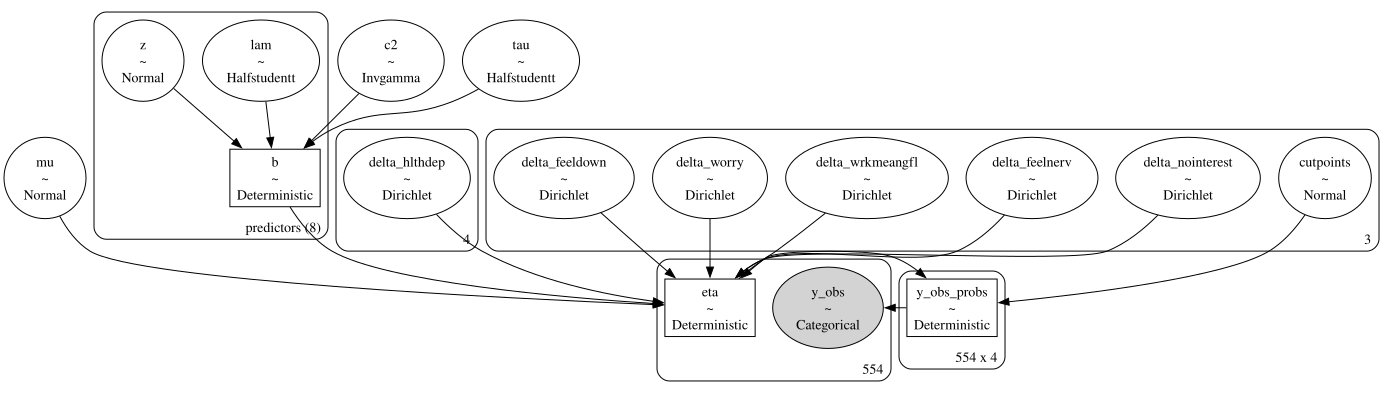

In [9]:
model.to_graphviz()

## Model Fitting

In [13]:
with model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        target_accept=0.9,
        nuts_sampler='nutpie'
    )
    pm.sample_posterior_predictive(trace, extend_inferencedata=True)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.16,63
,2000,0,0.13,63
,2000,0,0.15,63
,2000,0,0.15,63


Sampling: [y_obs]


Output()

Sampling complete!


## Convergence Diagnostics

In [14]:
# Check divergences
if 'diverging' in trace.sample_stats:
    n_div = int(trace.sample_stats['diverging'].sum().values)
    print(f'Divergent transitions: {n_div}')
    
# Scale parameter summary
print('\nScale parameters (b) - total effect from lowest to highest level:')
summary_b = az.summary(trace, var_names=['b'])
print(summary_b[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk']])

Divergent transitions: 0

Scale parameters (b) - total effect from lowest to highest level:
                mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
b[hlthdep]     1.174  0.403   0.455    1.969    1.0    3969.0
b[feeldown]   -0.093  0.322  -0.787    0.483    1.0    3772.0
b[nointerest]  0.137  0.334  -0.468    0.820    1.0    4573.0
b[feelnerv]    0.293  0.338  -0.254    0.967    1.0    3428.0
b[worry]      -0.033  0.291  -0.640    0.528    1.0    3819.0
b[wrkmeangfl]  3.215  0.438   2.420    4.044    1.0    3812.0
b[age]        -0.305  0.093  -0.474   -0.119    1.0    4147.0
b[female]      0.394  0.184   0.048    0.744    1.0    3304.0


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

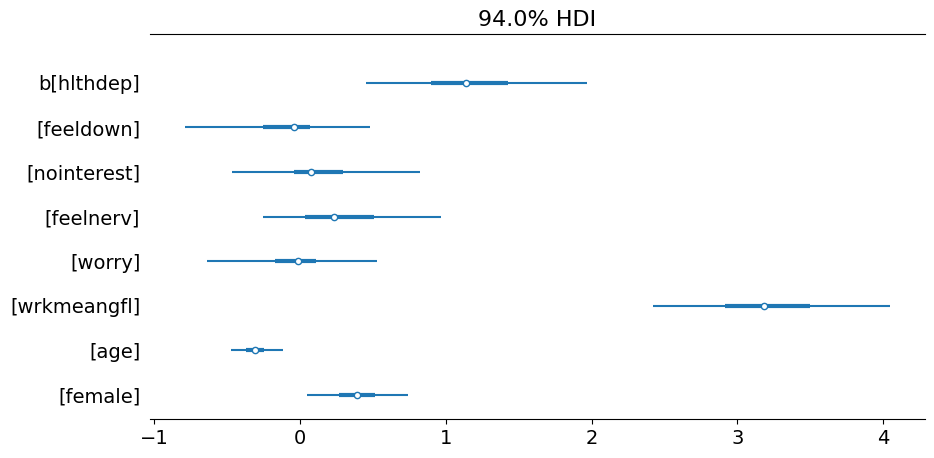

In [15]:
# Forest plot of scale parameters
az.plot_forest(trace, var_names=['b'], combined=True, figsize=(10, 5))

## Results: Scale Parameters

The scale parameter $b$ represents the **total effect** when moving from the lowest to highest level of each ordinal predictor. Positive values indicate higher levels predict lower job satisfaction (higher dissatisfaction codes).

In [16]:
# Detailed scale parameter analysis
b_samples = trace.posterior['b'].values.reshape(-1, D)

print('=== SCALE PARAMETER SUMMARY ===')
print('\nPositive b: higher levels → more dissatisfaction')
print('Negative b: higher levels → more satisfaction\n')

results = []
for i, name in enumerate(predictor_names):
    samples = b_samples[:, i]
    results.append({
        'Predictor': name,
        'Mean': samples.mean(),
        'SD': samples.std(),
        'HDI 3%': np.percentile(samples, 3),
        'HDI 97%': np.percentile(samples, 97),
        'P(b > 0)': (samples > 0).mean(),
        'P(|b| > 0.2)': (np.abs(samples) > 0.2).mean()
    })

results_df = pd.DataFrame(results).sort_values('P(|b| > 0.2)', ascending=False)
print(results_df.to_string(index=False, float_format='{:.3f}'.format))

=== SCALE PARAMETER SUMMARY ===

Positive b: higher levels → more dissatisfaction
Negative b: higher levels → more satisfaction

 Predictor   Mean    SD  HDI 3%  HDI 97%  P(b > 0)  P(|b| > 0.2)
wrkmeangfl  3.215 0.438   2.436    4.082     1.000         1.000
   hlthdep  1.174 0.402   0.473    2.010     0.999         0.995
       age -0.305 0.093  -0.485   -0.128     0.000         0.870
    female  0.394 0.184   0.043    0.742     0.985         0.852
  feelnerv  0.293 0.338  -0.213    1.033     0.816         0.569
nointerest  0.137 0.334  -0.420    0.890     0.655         0.449
  feeldown -0.093 0.322  -0.800    0.473     0.400         0.427
     worry -0.033 0.291  -0.642    0.525     0.459         0.388


## Monotonic Effect Shapes

The simplex parameters $\delta$ determine how the effect accumulates across levels. Let's visualize the shape of each monotonic effect.

In [17]:
# Compute and plot monotonic effect shapes
fig = make_subplots(rows=2, cols=3, subplot_titles=ordinal_predictors)

for i, var in enumerate(ordinal_predictors):
    row, col = i // 3 + 1, i % 3 + 1
    K_var = ordinal_K[var]
    
    # Get posterior samples
    delta_samples = trace.posterior[f'delta_{var}'].values.reshape(-1, K_var - 1)
    b_var_samples = b_samples[:, i]
    
    # Compute cumulative effects at each level
    effects = np.zeros((len(b_var_samples), K_var))
    for k in range(1, K_var):
        effects[:, k] = effects[:, k-1] + delta_samples[:, k-1]
    effects = effects * b_var_samples[:, None]  # scale by b
    
    # Plot mean and HDI
    levels = list(range(1, K_var + 1))  # original 1-indexed levels
    mean_effect = effects.mean(axis=0)
    hdi_low = np.percentile(effects, 3, axis=0)
    hdi_high = np.percentile(effects, 97, axis=0)
    
    fig.add_trace(
        go.Scatter(x=levels, y=mean_effect, mode='lines+markers',
                  name=var, line=dict(width=2), showlegend=False),
        row=row, col=col
    )
    fig.add_trace(
        go.Scatter(x=levels + levels[::-1], 
                  y=list(hdi_high) + list(hdi_low[::-1]),
                  fill='toself', fillcolor='rgba(0,100,200,0.2)',
                  line=dict(width=0), showlegend=False),
        row=row, col=col
    )
    fig.add_hline(y=0, line_dash='dash', line_color='gray', row=row, col=col)

fig.update_layout(height=500, title='Monotonic Effect Shapes (with 94% HDI)')
fig.update_xaxes(title_text='Level')
fig.update_yaxes(title_text='Effect on η')
fig.show()

print('Interpretation:')
print('  - Steep curves: large effect of moving between adjacent levels')
print('  - Flat sections: little additional effect at those levels')
print('  - Direction: positive slope = higher levels predict more dissatisfaction')

Interpretation:
  - Steep curves: large effect of moving between adjacent levels
  - Flat sections: little additional effect at those levels
  - Direction: positive slope = higher levels predict more dissatisfaction


In [18]:
# Summarize simplex (shape) parameters
print('=== SIMPLEX (SHAPE) PARAMETERS ===')
print('\nEach row shows the proportion of total effect between adjacent levels.\n')

for var in ordinal_predictors:
    K_var = ordinal_K[var]
    delta_samples = trace.posterior[f'delta_{var}'].values.reshape(-1, K_var - 1)
    
    print(f'{var} (levels 1-{K_var}):')
    for j in range(K_var - 1):
        mean_d = delta_samples[:, j].mean()
        print(f'  δ_{j+1} (level {j+1}→{j+2}): {mean_d:.3f} ({mean_d*100:.1f}% of total effect)')
    print()

=== SIMPLEX (SHAPE) PARAMETERS ===

Each row shows the proportion of total effect between adjacent levels.

hlthdep (levels 1-5):
  δ_1 (level 1→2): 0.493 (49.3% of total effect)
  δ_2 (level 2→3): 0.143 (14.3% of total effect)
  δ_3 (level 3→4): 0.138 (13.8% of total effect)
  δ_4 (level 4→5): 0.225 (22.5% of total effect)

feeldown (levels 1-4):
  δ_1 (level 1→2): 0.335 (33.5% of total effect)
  δ_2 (level 2→3): 0.319 (31.9% of total effect)
  δ_3 (level 3→4): 0.347 (34.7% of total effect)

nointerest (levels 1-4):
  δ_1 (level 1→2): 0.311 (31.1% of total effect)
  δ_2 (level 2→3): 0.320 (32.0% of total effect)
  δ_3 (level 3→4): 0.369 (36.9% of total effect)

feelnerv (levels 1-4):
  δ_1 (level 1→2): 0.312 (31.2% of total effect)
  δ_2 (level 2→3): 0.336 (33.6% of total effect)
  δ_3 (level 3→4): 0.352 (35.2% of total effect)

worry (levels 1-4):
  δ_1 (level 1→2): 0.325 (32.5% of total effect)
  δ_2 (level 2→3): 0.335 (33.5% of total effect)
  δ_3 (level 3→4): 0.340 (34.0% of total

## Shrinkage Analysis

In [19]:
# Analyze shrinkage
tau_samples = trace.posterior['tau'].values.flatten()
lam_samples = trace.posterior['lam'].values.reshape(-1, D)

# Shrinkage factor κ = 1 / (1 + τ²λ²)
kappa = 1 / (1 + (tau_samples[:, None] ** 2) * (lam_samples ** 2))

print('=== SHRINKAGE ANALYSIS ===')
print('\nκ near 1: strong shrinkage (toward 0)')
print('κ near 0: weak shrinkage (signal preserved)\n')

shrinkage_df = pd.DataFrame({
    'Predictor': predictor_names,
    'Mean |b|': np.abs(b_samples).mean(axis=0),
    'Mean κ': kappa.mean(axis=0),
    'P(κ > 0.5)': (kappa > 0.5).mean(axis=0)
}).sort_values('Mean κ')

print(shrinkage_df.to_string(index=False, float_format='{:.3f}'.format))
print(f'\nGlobal τ: mean={tau_samples.mean():.4f}, median={np.median(tau_samples):.4f}')

=== SHRINKAGE ANALYSIS ===

κ near 1: strong shrinkage (toward 0)
κ near 0: weak shrinkage (signal preserved)

 Predictor  Mean |b|  Mean κ  P(κ > 0.5)
wrkmeangfl     3.215   0.203       0.022
   hlthdep     1.174   0.455       0.443
    female     0.395   0.662       0.730
       age     0.305   0.690       0.771
  feelnerv     0.335   0.708       0.768
nointerest     0.251   0.735       0.790
  feeldown     0.235   0.746       0.802
     worry     0.207   0.751       0.808

Global τ: mean=1.0704, median=0.8017


## Posterior Predictive Check

In [20]:
# Posterior predictive check
obs_counts = pd.Series(y).value_counts().sort_index()
pp = trace.posterior_predictive['y_obs'].values

pred_counts = []
for chain in range(pp.shape[0]):
    for draw in range(pp.shape[1]):
        counts = pd.Series(pp[chain, draw, :]).value_counts()
        full = pd.Series(0, index=[0, 1, 2, 3])
        full.update(counts)
        pred_counts.append(full.values)

pred_counts = np.array(pred_counts)
pred_mean = pred_counts.mean(axis=0)
pred_q05, pred_q95 = np.percentile(pred_counts, [5, 95], axis=0)

cats = ['Very Satisfied', 'Mod. Satisfied', 'Little Dissatisfied', 'Very Dissatisfied']

fig = go.Figure()
fig.add_trace(go.Bar(x=cats, y=obs_counts.values, name='Observed', marker_color='darkblue'))
fig.add_trace(go.Bar(x=cats, y=pred_mean, name='Predicted (90% CI)', marker_color='lightcoral',
                     error_y=dict(type='data', array=pred_q95-pred_mean, arrayminus=pred_mean-pred_q05)))
fig.update_layout(title='Posterior Predictive Check', barmode='group',
                 xaxis_title='Job Satisfaction', yaxis_title='Count')
fig.show()

within = sum(pred_q05[i] <= obs_counts.iloc[i] <= pred_q95[i] for i in range(4))
print(f'Categories within 90% CI: {within}/4')

Categories within 90% CI: 4/4


## Conclusions

### Key Findings

Using monotonic effects with horseshoe priors, we identified:

1. **Strong predictors** (low shrinkage, large |b|): These ordinal predictors have clear monotonic relationships with job satisfaction that survive regularization.

2. **Weak/redundant predictors** (high shrinkage, small |b|): These are shrunk toward zero, suggesting they don't add unique predictive information beyond the strong predictors.

3. **Effect shapes**: The simplex parameters reveal whether effects accumulate uniformly across levels or concentrate at specific transitions.

### Advantages of This Approach

1. **Respects ordinality**: No assumption of equal spacing between predictor levels
2. **Monotonic constraint**: Effects can only increase or decrease, matching theoretical expectations
3. **Adaptive regularization**: Horseshoe distinguishes signal from noise among correlated predictors
4. **Interpretable**: Scale (b) gives total effect; simplex (δ) gives shape

### Limitations

- Several requested variables unavailable in dataset
- Sample size (554) limits detection of small effects
- Cross-sectional design precludes causal inference